In [270]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mutual_info_score

df = pd.read_csv("../data/train.csv")

df.head()

,Property_ID,City,Locality_Type,Property_Type,BHK,Bathrooms,Super_Area_SqFt,Carpet_Area_SqFt,Floor_Number,Total_Floors,Age_of_Property,Furnishing_Status,Parking,Lift_Available,Gated_Community,Distance_to_Metro_km,Distance_to_City_Center_km,Price_INR_Lakhs
0,PROP-005003,Chandigarh,Mid-Range,Builder Floor,4,5,1293.82,862.81,21,36,11,Semi-Furnished,1,1,1,5.34,10.84,127.38
1,PROP-009920,Kolkata,Premium,Builder Floor,2,2,2438.03,1977.23,16,31,16,Semi-Furnished,1,1,1,3.48,8.69,214.61
2,PROP-003987,Delhi,Mid-Range,Villa,3,4,1065.54,721.68,2,3,32,Semi-Furnished,0,0,1,2.66,5.73,162.56
3,PROP-084186,Chandigarh,Mid-Range,Apartment,1,2,1611.76,1327.15,38,41,27,Semi-Furnished,1,1,0,1.33,10.70,124.88
4,PROP-068764,Ahmedabad,Premium,Independent House,5,5,1043.93,781.81,21,30,23,Unfurnished,0,1,0,1.75,7.22,94.77


In [271]:
print(df.isnull().sum())
print(df.isna().sum())

df.head()

df = df.drop(columns=["Property_ID"])

Property_ID                   0
City                          0
Locality_Type                 0
Property_Type                 0
BHK                           0
Bathrooms                     0
Super_Area_SqFt               0
Carpet_Area_SqFt              0
Floor_Number                  0
Total_Floors                  0
Age_of_Property               0
Furnishing_Status             0
Parking                       0
Lift_Available                0
Gated_Community               0
Distance_to_Metro_km          0
Distance_to_City_Center_km    0
Price_INR_Lakhs               0
dtype: int64
Property_ID                   0
City                          0
Locality_Type                 0
Property_Type                 0
BHK                           0
Bathrooms                     0
Super_Area_SqFt               0
Carpet_Area_SqFt              0
Floor_Number                  0
Total_Floors                  0
Age_of_Property               0
Furnishing_Status             0
Parking                    

In [ ]:
sns.histplot(df["Price_INR_Lakhs"], kde=True, bins = 5)




In [ ]:
sns.scatterplot(data=df, x = "Super_Area_SqFt", y = "Price_INR_Lakhs")

plt.show()



In [ ]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(35, 25))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()



In [273]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["Price_INR_Lakhs"])
y = df["Price_INR_Lakhs"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [274]:
df

,City,Locality_Type,Property_Type,BHK,Bathrooms,Super_Area_SqFt,Carpet_Area_SqFt,Floor_Number,Total_Floors,Age_of_Property,Furnishing_Status,Parking,Lift_Available,Gated_Community,Distance_to_Metro_km,Distance_to_City_Center_km,Price_INR_Lakhs
0,Chandigarh,Mid-Range,Builder Floor,4,5,1293.82,862.81,21,36,11,Semi-Furnished,1,1,1,5.34,10.84,127.38
1,Kolkata,Premium,Builder Floor,2,2,2438.03,1977.23,16,31,16,Semi-Furnished,1,1,1,3.48,8.69,214.61
2,Delhi,Mid-Range,Villa,3,4,1065.54,721.68,2,3,32,Semi-Furnished,0,0,1,2.66,5.73,162.56
3,Chandigarh,Mid-Range,Apartment,1,2,1611.76,1327.15,38,41,27,Semi-Furnished,1,1,0,1.33,10.70,124.88
4,Ahmedabad,Premium,Independent House,5,5,1043.93,781.81,21,30,23,Unfurnished,0,1,0,1.75,7.22,94.77
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79995,Jaipur,Affordable,Independent House,2,3,819.46,562.11,1,6,37,Semi-Furnished,1,1,1,4.45,9.22,18.80
79996,Chandigarh,Affordable,Builder Floor,4,4,711.22,483.28,24,30,16,Unfurnished,1,1,1,1.09,8.13,30.90
79997,Chennai,Mid-Range,Villa,2,3,1223.19,835.26,17,27,17,Unfurnished,1,1,0,2.53,0.53,129.89
79998,Hyderabad,Affordable,Apartment,2,3,439.18,338.47,3,29,28,Furnished,1,1,1,5.18,14.35,15.44


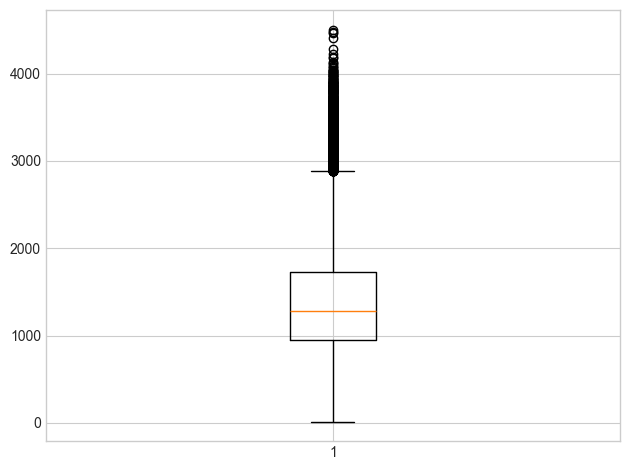

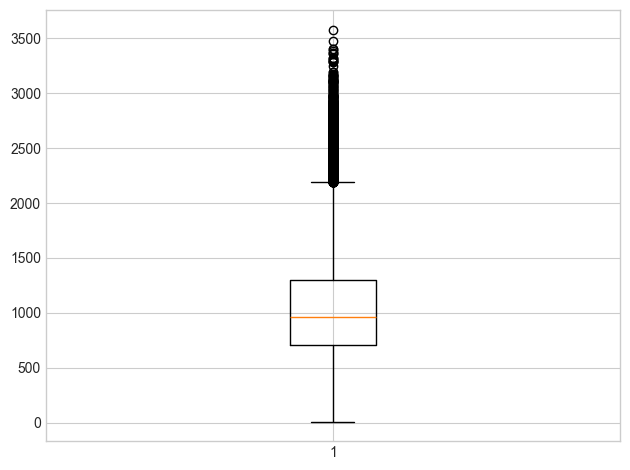

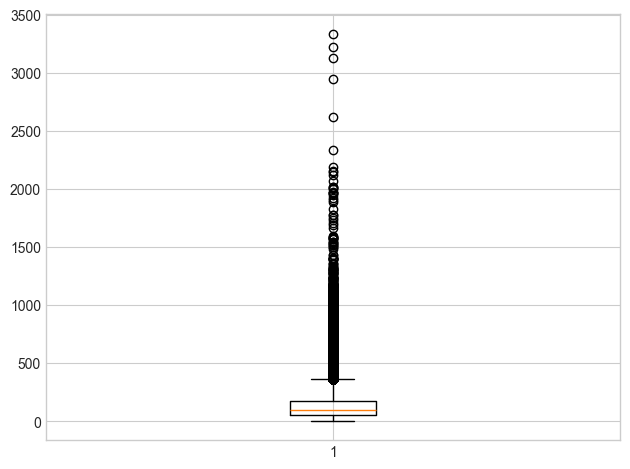

In [247]:
for i in ['Super_Area_SqFt', 'Carpet_Area_SqFt',"Price_INR_Lakhs"]:
    plt.boxplot(df[i])
    plt.show()

In [ ]:
#DO NOT USE IT!!!!!!!

Q1 = y_train.quantile(0.25)
Q3 = y_train.quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

In [ ]:
#DO NOT USE IT!!!!!!!

mask = (y_train >= lower) & (y_train <= upper)

X_train = X_train[mask]
y_train = y_train[mask]

In [278]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder


pip_num = Pipeline([
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler", StandardScaler())
    
])

pip_cat_one = Pipeline([
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown = "ignore"))
])

pip_cat_ord = Pipeline([
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("ordinal", OrdinalEncoder(categories=[["Affordable", "Mid-Range", "Premium"],["Unfurnished", "Semi-Furnished", "Furnished"]]))
])
pip_cat_ord1 = Pipeline([
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("ordinal", OrdinalEncoder(categories=[["Unfurnished", "Semi-Furnished", "Furnished"], ]))
])

num_cols = ["Super_Area_SqFt", "Carpet_Area_SqFt", "Age_of_Property", "Distance_to_City_Center_km", "Total_Floors"]
cat_cols = ["Locality_Type", "City"]


In [279]:
num_cols = X_train.select_dtypes(include=["int64", "float64"]).columns.tolist()
one_cols = ["City", "Property_Type"]
ord_cols = ["Locality_Type","Furnishing_Status"]

preprocessor = ColumnTransformer([
    ("num", pip_num, num_cols),
    ("onehot", pip_cat_one, one_cols),
    ("ordinal", pip_cat_ord, ord_cols),
    
])

In [289]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_predict, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

pip = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
    
])

pip.fit(X_train, y_train)

y_pred = pip.predict(X_test)

MSE = mean_squared_error(y_test, y_pred)
R2 = r2_score(y_test,y_pred)


print("MSE: ",MSE)
print("RMSE: ", np.sqrt(MSE))
print("R2: ",R2)



MSE:  7632.344556539645
RMSE:  87.36329066913429
R2:  0.6552695407630442


In [287]:
scores = cross_val_score(pip, X_train, y_train, cv=5, scoring="r2")

print(scores)

print((scores).mean())


[0.65404266 0.66030673 0.65928353 0.66183136 0.66801467]
0.6606957901945091


In [288]:
from sklearn.ensemble import RandomForestRegressor


pip_rand = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(n_estimators=200, random_state=42,min_samples_split = 10, min_samples_leaf=2,max_features=0.5,max_depth=None))
    
])

pip_rand.fit(X_train, y_train)

y_pred = pip_rand.predict(X_test)

MSE = mean_squared_error(y_pred, y_test)
R2 = r2_score(y_test,y_pred)


print("MSE: ",MSE)
print("RMSE: ", np.sqrt(MSE))
print("R2: ",R2)

MSE:  4754.14322325811
RMSE:  68.95029530943367
R2:  0.7852693933703808


In [283]:
cv = cross_val_score(pip_rand, X_train, y_train, cv=5, scoring="r2")

print(cv)

[0.7739336  0.78279382 0.7754063  0.78807079 0.78713934]


In [290]:
from xgboost import XGBRegressor

final_pip = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBRegressor())])

final_pip.fit(X_train, y_train)
y_pred = final_pip.predict(X_test)
MSE =  mean_squared_error(y_test, y_pred)
print("MSE:", MSE)
print("RMSE: ", np.sqrt(MSE))
print("R2:", r2_score(y_test, y_pred))

MSE: 5007.262150077186
RMSE:  70.76201064184924
R2: 0.7738367591074085


In [285]:
cv_XG = cross_val_score(final_pip, X_train, y_train, cv=5, scoring="r2")

print(cv_XG)

[0.76598926 0.76288894 0.75130184 0.77498998 0.7674313 ]
